# 02 — DDPM: Denoising Diffusion Probabilistic Models

We build DDPM from scratch, piece by piece, with visualizations at every step.

**Structure:**
1. Noise Schedule — how noise is added
2. Forward Process — corrupting images
3. Model Building Blocks — time embedding, ResBlock, Attention
4. U-Net — the full neural network
5. Training — the loss and training loop
6. Sampling — reversing the process to generate images

**Run locally up to section 4. Train on Colab.**

In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from dataclasses import dataclass
from typing import Tuple
import os

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cuda


In [ ]:
@dataclass
class DDPMConfig:
    # Data
    image_size: int = 32
    channels: int = 3

    # Noise schedule
    T: int = 1000               # total diffusion steps
    schedule: str = 'cosine'    # 'linear' or 'cosine' (cosine is better for small images)
    beta_start: float = 1e-4   # only used if schedule='linear'
    beta_end: float = 0.02     # only used if schedule='linear'

    # Model
    model_channels: int = 128   # base channel count
    num_heads: int = 4
    dropout: float = 0.1
    num_groups: int = 32        # for GroupNorm

    # Training
    batch_size: int = 128
    lr: float = 2e-4
    num_epochs: int = 500
    grad_clip: float = 1.0
    ema_decay: float = 0.9999

    # Sampling
    clip_denoised: bool = True

cfg = DDPMConfig()

# Smaller config for local sanity checks (no GPU needed)
cfg_tiny = DDPMConfig(model_channels=32, num_heads=2, num_groups=8)

print('Config ready.')

---
## Section 1: Noise Schedule

DDPM adds noise in T=1000 small steps. Each step t adds a tiny bit more noise, controlled by a scalar βₜ.

Instead of applying noise step by step, there's a closed-form shortcut:

> **x_t = √ᾱₜ · x₀ + √(1−ᾱₜ) · ε**,   ε ~ N(0, I)

Where ᾱₜ = α₁ · α₂ · ... · αₜ and αₜ = 1 − βₜ.

At t=0: ᾱ₀ ≈ 1, so x₀ ≈ x₀ (clean image)  
At t=T: ᾱₜ ≈ 0, so xₜ ≈ noise

**Cosine schedule** (Nichol & Dhariwal, 2021) is better than linear for small images like CIFAR-10 — it adds noise more gradually at the start.

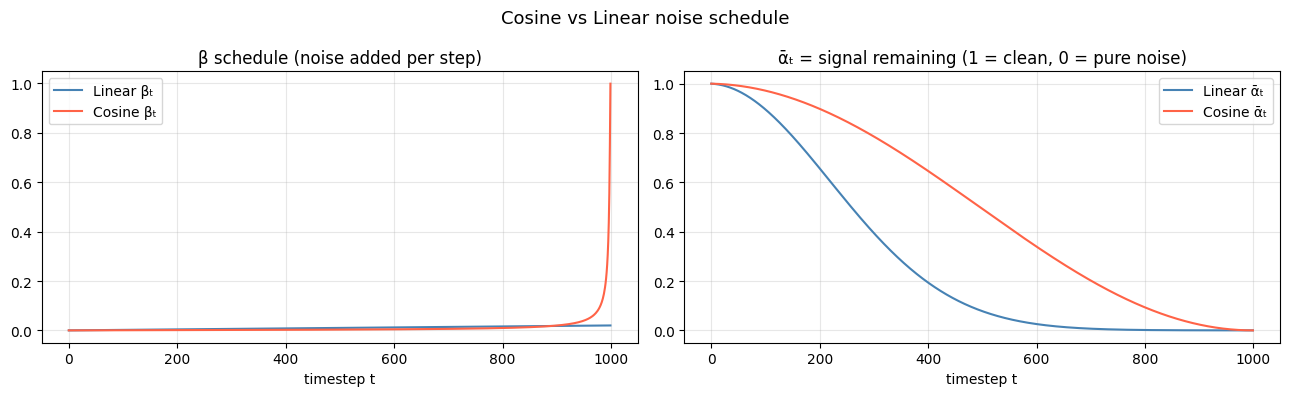

Linear: signal at t=500 = 0.078, t=T = 0.0000
Cosine: signal at t=500 = 0.492, t=T = 0.0000


In [4]:
def linear_schedule(T, beta_start=1e-4, beta_end=0.02):
    return torch.linspace(beta_start, beta_end, T)

def cosine_schedule(T, s=0.008):
    """Nichol & Dhariwal 2021 — smoother noise addition than linear."""
    steps = T + 1
    t = torch.linspace(0, T, steps) / T
    f = torch.cos((t + s) / (1 + s) * math.pi / 2) ** 2
    alphas_cumprod = f / f[0]                                  # normalize so f(0) = 1
    betas = 1 - alphas_cumprod[1:] / alphas_cumprod[:-1]      # reverse engineer betas
    return betas.clamp(0, 0.999)                               # clamp for numerical stability

# Visualize both schedules
T = 1000
betas_linear = linear_schedule(T)
betas_cosine = cosine_schedule(T)

alphas_linear = torch.cumprod(1 - betas_linear, dim=0)
alphas_cosine = torch.cumprod(1 - betas_cosine, dim=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
t_range = range(T)

axes[0].plot(t_range, betas_linear.numpy(), label='Linear βₜ', color='steelblue')
axes[0].plot(t_range, betas_cosine.numpy(), label='Cosine βₜ', color='tomato')
axes[0].set_title('β schedule (noise added per step)')
axes[0].set_xlabel('timestep t')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_range, alphas_linear.numpy(), label='Linear ᾱₜ', color='steelblue')
axes[1].plot(t_range, alphas_cosine.numpy(), label='Cosine ᾱₜ', color='tomato')
axes[1].set_title('ᾱₜ = signal remaining (1 = clean, 0 = pure noise)')
axes[1].set_xlabel('timestep t')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Cosine vs Linear noise schedule', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Linear: signal at t=500 = {alphas_linear[500]:.3f}, t=T = {alphas_linear[-1]:.4f}')
print(f'Cosine: signal at t=500 = {alphas_cosine[500]:.3f}, t=T = {alphas_cosine[-1]:.4f}')

---
## Section 2: Forward Process

The `NoiseScheduler` precomputes everything once, then `q_sample` applies the closed-form corruption.

We also precompute the quantities needed for the **reverse** process:
- `sqrt_recip_alphas` — for recovering x̂₀
- `posterior_variance` — controls the noise added at each reverse step

In [ ]:
class NoiseScheduler:
    def __init__(self, cfg: DDPMConfig):
        self.T = cfg.T

        # --- Compute betas ---
        if cfg.schedule == 'linear':
            betas = linear_schedule(cfg.T, cfg.beta_start, cfg.beta_end)
        else:
            betas = cosine_schedule(cfg.T)

        alphas = 1.0 - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)                         # ᾱₜ
        alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)  # ᾱₜ₋₁

        # --- Store all quantities we'll need ---
        self.betas = betas
        self.alphas_cumprod = alphas_cumprod
        self.alphas_cumprod_prev = alphas_cumprod_prev

        # Forward process q(xₜ|x₀)
        self.sqrt_alphas_cumprod = alphas_cumprod.sqrt()         # √ᾱₜ
        self.sqrt_one_minus_ac   = (1 - alphas_cumprod).sqrt()  # √(1−ᾱₜ)

        # Reverse process p(xₜ₋₁|xₜ)
        self.sqrt_recip_alphas = (1.0 / alphas).sqrt()           # 1/√αₜ
        # posterior variance β̃ₜ = βₜ · (1−ᾱₜ₋₁)/(1−ᾱₜ)
        self.posterior_variance = betas * (1 - alphas_cumprod_prev) / (1 - alphas_cumprod)

        # Posterior mean coefficients: μ̃ₜ = coeff1 · x̂₀ + coeff2 · xₜ
        self.posterior_mean_coeff1 = (alphas_cumprod_prev.sqrt() * betas) / (1 - alphas_cumprod)
        self.posterior_mean_coeff2 = (alphas.sqrt() * (1 - alphas_cumprod_prev)) / (1 - alphas_cumprod)

    def q_sample(self, x0: torch.Tensor, t: torch.Tensor, noise: torch.Tensor = None):
        """Forward process: corrupt x0 to xₜ in one shot.
        x_t = √ᾱₜ · x0 + √(1−ᾱₜ) · ε
        Returns (x_t, noise) — we need the noise for the training target.
        """
        if noise is None:
            noise = torch.randn_like(x0)

        # Index into precomputed tensors using t, reshape for broadcasting: [B] -> [B, 1, 1, 1]
        # .to(x0.device) so this works on GPU without bouncing tensors to CPU
        sqrt_ac  = self.sqrt_alphas_cumprod[t].to(x0.device)[:, None, None, None]
        sqrt_omc = self.sqrt_one_minus_ac[t].to(x0.device)[:, None, None, None]

        return sqrt_ac * x0 + sqrt_omc * noise, noise

scheduler = NoiseScheduler(cfg)
print('NoiseScheduler ready.')
print(f'  betas shape          : {scheduler.betas.shape}')
print(f'  alphas_cumprod shape : {scheduler.alphas_cumprod.shape}')

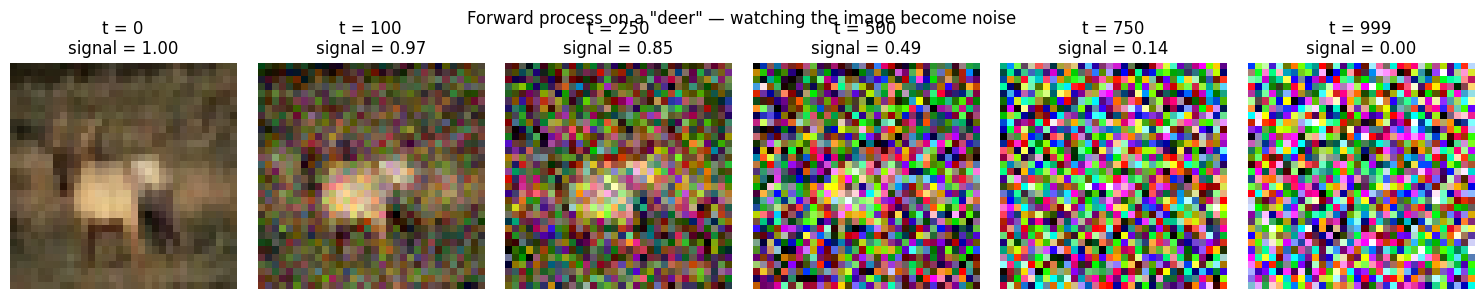

At t=999 the image is almost pure Gaussian noise — this is what the model starts from when generating.


In [7]:
# Load one real image to visualize the forward process
raw_dataset = datasets.CIFAR10(root='./data', train=True, download=True,
                                transform=transforms.Compose([
                                    transforms.ToTensor(),
                                    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
                                ]))

CLASSES = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

torch.manual_seed(0)
x0, label = raw_dataset[3]  # pick an image
x0 = x0.unsqueeze(0)        # add batch dim: [1, 3, 32, 32]

timesteps_to_show = [0, 100, 250, 500, 750, 999]

fig, axes = plt.subplots(1, len(timesteps_to_show), figsize=(15, 3))
fig.suptitle(f'Forward process on a "{CLASSES[label]}" — watching the image become noise', fontsize=12)

for ax, t_val in zip(axes, timesteps_to_show):
    t_tensor = torch.tensor([t_val])
    x_t, _ = scheduler.q_sample(x0, t_tensor)
    img = ((x_t.squeeze() + 1) / 2).clamp(0, 1).permute(1, 2, 0).numpy()

    # Show remaining signal at this timestep
    signal = scheduler.alphas_cumprod[t_val].item()
    ax.imshow(img)
    ax.set_title(f't = {t_val}\nsignal = {signal:.2f}')
    ax.axis('off')

plt.tight_layout()
plt.show()
print('At t=999 the image is almost pure Gaussian noise — this is what the model starts from when generating.')

---
## Section 3: Model Building Blocks

The U-Net needs three custom building blocks:

**TimeEmbedding** — encodes the timestep t into a vector the network can use.  
**ResBlock** — the core computation block. Applies convolutions and injects the time signal.  
**SelfAttention** — lets the model look at the global image context (only at low resolutions).

### 3.1 Time Embedding
t is a single integer per image. We need to turn it into a rich vector the network can use.
- First: sinusoidal encoding (like transformers) — gives a unique pattern for each t
- Then: 2-layer MLP to learn useful features from it

Input timesteps shape : torch.Size([4])
Output embedding shape: torch.Size([4, 128])


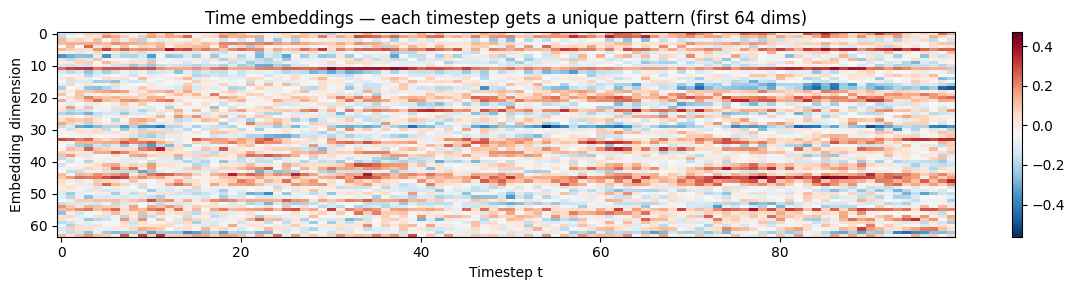

In [8]:
class TimeEmbedding(nn.Module):
    """Timestep t -> rich embedding vector.
    Sinusoidal encoding -> 2-layer MLP.
    """
    def __init__(self, base_dim: int):
        super().__init__()
        emb_dim = base_dim * 4   # expand for more capacity
        self.base_dim = base_dim
        self.mlp = nn.Sequential(
            nn.Linear(base_dim, emb_dim),
            nn.SiLU(),
            nn.Linear(emb_dim, emb_dim)
        )

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        # Sinusoidal encoding: same idea as transformer positional encoding
        half = self.base_dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, device=t.device) / (half - 1)
        )                                       # [half]
        emb = t[:, None].float() * freqs[None]  # [B, half]
        emb = torch.cat([emb.sin(), emb.cos()], dim=-1)  # [B, base_dim]
        return self.mlp(emb)                    # [B, base_dim * 4]


# --- Quick test ---
t_emb_module = TimeEmbedding(cfg_tiny.model_channels)
dummy_t = torch.randint(0, 1000, (4,))         # batch of 4 timesteps
emb_out = t_emb_module(dummy_t)
print(f'Input timesteps shape : {dummy_t.shape}')    # [4]
print(f'Output embedding shape: {emb_out.shape}')    # [4, base_dim*4]

# Visualize: each row is a different timestep, each col is an embedding dim
with torch.no_grad():
    t_all = torch.arange(0, 1000, 10)
    embs  = TimeEmbedding(32)(t_all)

plt.figure(figsize=(12, 3))
plt.imshow(embs[:, :64].numpy().T, aspect='auto', cmap='RdBu_r')
plt.xlabel('Timestep t')
plt.ylabel('Embedding dimension')
plt.title('Time embeddings — each timestep gets a unique pattern (first 64 dims)')
plt.colorbar()
plt.tight_layout()
plt.show()

### 3.2 Residual Block

Two convolutions with GroupNorm + SiLU activation, plus a skip connection.

**Key:** the time embedding is injected using **scale and shift** (also called FiLM conditioning):  
After the first conv, we compute `scale` and `shift` from the time embedding and apply:  
> h = h · (scale + 1) + shift

This is more expressive than just adding the time embedding.

In [9]:
class ResBlock(nn.Module):
    """Core residual block with time conditioning.
    in_ch -> out_ch, with skip connection.
    """
    def __init__(self, in_ch: int, out_ch: int, time_emb_dim: int,
                 num_groups: int = 32, dropout: float = 0.1):
        super().__init__()
        self.norm1 = nn.GroupNorm(num_groups, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)

        # Time MLP: produces scale and shift (2 * out_ch values)
        self.time_mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_emb_dim, out_ch * 2)
        )

        self.norm2   = nn.GroupNorm(num_groups, out_ch)
        self.dropout = nn.Dropout(dropout)
        self.conv2   = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.act     = nn.SiLU()

        # Skip connection — 1x1 conv if channel count changes, else identity
        self.shortcut = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x: torch.Tensor, t_emb: torch.Tensor) -> torch.Tensor:
        h = self.conv1(self.act(self.norm1(x)))  # first conv

        # Inject time: split into scale and shift, reshape for broadcasting [B, C] -> [B, C, 1, 1]
        scale, shift = self.time_mlp(t_emb).chunk(2, dim=-1)
        h = h * (scale[:, :, None, None] + 1) + shift[:, :, None, None]

        h = self.dropout(self.conv2(self.act(self.norm2(h))))  # second conv
        return h + self.shortcut(x)              # residual


# --- Quick test ---
ch = cfg_tiny.model_channels
t_dim = ch * 4
dummy_x   = torch.randn(4, ch, 16, 16)
dummy_temb = torch.randn(4, t_dim)

rb = ResBlock(in_ch=ch, out_ch=ch*2, time_emb_dim=t_dim, num_groups=cfg_tiny.num_groups)
out = rb(dummy_x, dummy_temb)
print(f'ResBlock input  shape: {dummy_x.shape}')   # [4, ch, 16, 16]
print(f'ResBlock output shape: {out.shape}')        # [4, ch*2, 16, 16]  — channels doubled

ResBlock input  shape: torch.Size([4, 32, 16, 16])
ResBlock output shape: torch.Size([4, 64, 16, 16])


### 3.3 Self-Attention

Applied only at low-resolution feature maps (16×16, 8×8) where it's affordable.  
Lets every spatial position attend to every other — captures global structure.

Uses PyTorch's built-in `scaled_dot_product_attention` (efficient, Flash Attention compatible).

In [10]:
class SelfAttention(nn.Module):
    """Multi-head self-attention over spatial positions.
    Residual: output = x + Attention(Norm(x))
    """
    def __init__(self, channels: int, num_heads: int = 4, num_groups: int = 32):
        super().__init__()
        assert channels % num_heads == 0, 'channels must be divisible by num_heads'
        self.num_heads = num_heads
        self.head_dim  = channels // num_heads

        self.norm   = nn.GroupNorm(num_groups, channels)
        self.to_qkv = nn.Conv2d(channels, channels * 3, 1, bias=False)  # Q, K, V in one shot
        self.to_out = nn.Conv2d(channels, channels, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, C, H, W = x.shape
        h = self.norm(x)

        # Project to Q, K, V and split into heads
        qkv = self.to_qkv(h)                           # [B, 3C, H, W]
        qkv = qkv.reshape(B, 3, self.num_heads, self.head_dim, H * W)
        qkv = qkv.permute(1, 0, 2, 4, 3)               # [3, B, heads, HW, head_dim]
        q, k, v = qkv[0], qkv[1], qkv[2]

        # Scaled dot-product attention
        attn = F.scaled_dot_product_attention(q, k, v)  # [B, heads, HW, head_dim]

        # Merge heads and project back
        attn = attn.permute(0, 1, 3, 2).reshape(B, C, H, W)
        return x + self.to_out(attn)                    # residual


# --- Quick test ---
dummy_feat = torch.randn(4, 64, 16, 16)
attn_layer = SelfAttention(channels=64, num_heads=4, num_groups=8)
attn_out   = attn_layer(dummy_feat)
print(f'Attention input  shape: {dummy_feat.shape}')  # [4, 64, 16, 16]
print(f'Attention output shape: {attn_out.shape}')    # [4, 64, 16, 16] — same, it's a residual

Attention input  shape: torch.Size([4, 64, 16, 16])
Attention output shape: torch.Size([4, 64, 16, 16])


---
## Section 4: U-Net

```
x [B, 3, 32, 32]
        │
   init_conv
        │  [B, ch, 32, 32]
  ┌─────┴─────────────────────────────────────────────┐
  │  enc1: ResBlock, ResBlock                   skip1 │  32×32
  │        Downsample ──────────────────────────────► │
  │  enc2: ResBlock, ResBlock, Attention        skip2 │  16×16
  │        Downsample                                 │
  │  enc3: ResBlock, ResBlock, Attention        skip3 │   8×8
  │        Downsample                                 │
  │  mid:  ResBlock, Attention, ResBlock              │   4×4
  │        Upsample                                   │
  │  dec3: cat(skip3) → ResBlock, ResBlock, Attn      │   8×8
  │        Upsample                                   │
  │  dec2: cat(skip2) → ResBlock, ResBlock, Attn      │  16×16
  │        Upsample                                   │
  │  dec1: cat(skip1) → ResBlock, ResBlock            │  32×32
  └─────────────────────────────────────────────────► │
        │
    out_conv
        │  [B, 3, 32, 32]  — predicted noise ε̂
```

In [11]:
class Downsample(nn.Module):
    """Halve spatial size using stride-2 conv (learnable, better than pooling)."""
    def __init__(self, channels: int):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, 3, stride=2, padding=1)

    def forward(self, x):
        return self.conv(x)


class Upsample(nn.Module):
    """Double spatial size using nearest-neighbor + conv (avoids checkerboard artifacts)."""
    def __init__(self, channels: int):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, 3, padding=1)

    def forward(self, x):
        x = F.interpolate(x, scale_factor=2, mode='nearest')
        return self.conv(x)

In [12]:
class UNet(nn.Module):
    """U-Net that takes a noisy image and timestep, predicts the noise.
    Input : (x_t [B,3,32,32], t [B]) 
    Output: ε̂   [B,3,32,32]
    """
    def __init__(self, cfg: DDPMConfig):
        super().__init__()
        ch    = cfg.model_channels
        t_dim = ch * 4
        ng    = cfg.num_groups
        nh    = cfg.num_heads
        do    = cfg.dropout

        # --- Time embedding ---
        self.time_emb = TimeEmbedding(ch)
        # t_dim = ch * 4 (set inside TimeEmbedding)

        # --- Initial projection: 3 channels -> ch ---
        self.init_conv = nn.Conv2d(3, ch, 3, padding=1)

        # ============================================================
        # ENCODER  (save skip connections at each resolution)
        # ============================================================

        # 32×32, ch channels
        self.enc1_a = ResBlock(ch,    ch,    t_dim, ng, do)
        self.enc1_b = ResBlock(ch,    ch,    t_dim, ng, do)
        self.down1  = Downsample(ch)                        # -> 16×16

        # 16×16, ch*2 channels
        self.enc2_a = ResBlock(ch,    ch*2,  t_dim, ng, do)
        self.enc2_b = ResBlock(ch*2,  ch*2,  t_dim, ng, do)
        self.attn2  = SelfAttention(ch*2, nh, ng)
        self.down2  = Downsample(ch*2)                      # -> 8×8

        # 8×8, ch*2 channels
        self.enc3_a = ResBlock(ch*2,  ch*2,  t_dim, ng, do)
        self.enc3_b = ResBlock(ch*2,  ch*2,  t_dim, ng, do)
        self.attn3  = SelfAttention(ch*2, nh, ng)
        self.down3  = Downsample(ch*2)                      # -> 4×4

        # ============================================================
        # BOTTLENECK  4×4, ch*2 channels
        # ============================================================
        self.mid1      = ResBlock(ch*2, ch*2, t_dim, ng, do)
        self.mid_attn  = SelfAttention(ch*2, nh, ng)
        self.mid2      = ResBlock(ch*2, ch*2, t_dim, ng, do)

        # ============================================================
        # DECODER  (cat with skip then process)
        # ============================================================

        # 4×4 -> 8×8, in_ch = ch*2 (up) + ch*2 (skip3) = ch*4
        self.up3    = Upsample(ch*2)
        self.dec3_a = ResBlock(ch*4,  ch*2,  t_dim, ng, do)
        self.dec3_b = ResBlock(ch*2,  ch*2,  t_dim, ng, do)
        self.dattn3 = SelfAttention(ch*2, nh, ng)

        # 8×8 -> 16×16, in_ch = ch*2 (up) + ch*2 (skip2) = ch*4
        self.up2    = Upsample(ch*2)
        self.dec2_a = ResBlock(ch*4,  ch*2,  t_dim, ng, do)
        self.dec2_b = ResBlock(ch*2,  ch*2,  t_dim, ng, do)
        self.dattn2 = SelfAttention(ch*2, nh, ng)

        # 16×16 -> 32×32, in_ch = ch*2 (up) + ch (skip1) = ch*3
        self.up1    = Upsample(ch*2)
        self.dec1_a = ResBlock(ch*3,  ch,    t_dim, ng, do)
        self.dec1_b = ResBlock(ch,    ch,    t_dim, ng, do)

        # ============================================================
        # OUTPUT HEAD
        # ============================================================
        self.out_norm = nn.GroupNorm(ng, ch)
        self.out_conv = nn.Conv2d(ch, 3, 1)   # 1×1 conv to predict noise

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        # Time embedding: [B] -> [B, ch*4]
        t_emb = self.time_emb(t)

        # Initial projection
        h = self.init_conv(x)                                  # [B, ch, 32, 32]

        # ---- ENCODER ----
        # 32×32
        h  = self.enc1_b(self.enc1_a(h, t_emb), t_emb)        # [B, ch, 32, 32]
        s1 = h                                                  # save skip

        # 16×16
        h  = self.attn2(self.enc2_b(self.enc2_a(self.down1(h), t_emb), t_emb))
        s2 = h                                                  # save skip

        # 8×8
        h  = self.attn3(self.enc3_b(self.enc3_a(self.down2(h), t_emb), t_emb))
        s3 = h                                                  # save skip

        # ---- BOTTLENECK ----
        h = self.down3(h)                                       # [B, ch*2, 4, 4]
        h = self.mid1(h, t_emb)
        h = self.mid_attn(h)
        h = self.mid2(h, t_emb)

        # ---- DECODER ----
        # 4×4 -> 8×8
        h = torch.cat([self.up3(h), s3], dim=1)                # concat skip3
        h = self.dattn3(self.dec3_b(self.dec3_a(h, t_emb), t_emb))

        # 8×8 -> 16×16
        h = torch.cat([self.up2(h), s2], dim=1)                # concat skip2
        h = self.dattn2(self.dec2_b(self.dec2_a(h, t_emb), t_emb))

        # 16×16 -> 32×32
        h = torch.cat([self.up1(h), s1], dim=1)                # concat skip1
        h = self.dec1_b(self.dec1_a(h, t_emb), t_emb)

        # ---- OUTPUT ----
        return self.out_conv(F.silu(self.out_norm(h)))          # [B, 3, 32, 32]

In [13]:
# --- Sanity check: forward pass with tiny config ---
# Run this on CPU to verify shapes are correct before going to Colab
torch.manual_seed(0)
model_tiny = UNet(cfg_tiny)

dummy_img = torch.randn(2, 3, 32, 32)   # batch of 2 images
dummy_t   = torch.randint(0, 1000, (2,))

with torch.no_grad():
    out = model_tiny(dummy_img, dummy_t)

print(f'Input shape  : {dummy_img.shape}')  # [2, 3, 32, 32]
print(f'Output shape : {out.shape}')        # [2, 3, 32, 32]  <- must match input
assert out.shape == dummy_img.shape, 'Shape mismatch!'
print('Shape check passed!')

# Parameter count
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model_full = UNet(cfg)
print(f'\nTiny model parameters : {count_params(model_tiny)/1e6:.2f}M')
print(f'Full model parameters : {count_params(model_full)/1e6:.2f}M')

Input shape  : torch.Size([2, 3, 32, 32])
Output shape : torch.Size([2, 3, 32, 32])
Shape check passed!

Tiny model parameters : 1.41M
Full model parameters : 22.42M


---
## Section 5: Training

**The DDPM training step (one batch):**
1. Sample random timesteps t ~ Uniform{1,...,T}
2. Sample noise ε ~ N(0, I)
3. Corrupt the batch: xₜ = √ᾱₜ · x₀ + √(1−ᾱₜ) · ε
4. Predict: ε̂ = UNet(xₜ, t)
5. Loss = MSE(ε̂, ε)
6. Backprop + update

**EMA (Exponential Moving Average):** We keep a shadow copy of the weights that slowly tracks the trained weights. EMA weights produce much better samples than the raw trained weights.

In [14]:
class EMA:
    """Exponential Moving Average of model weights.
    Use ema.apply() to switch to EMA weights for sampling.
    Use ema.restore() to switch back to training weights.
    """
    def __init__(self, model: nn.Module, decay: float = 0.9999):
        self.model  = model
        self.decay  = decay
        # Initialize shadow weights as a copy of the current model
        self.shadow = {name: param.data.clone()
                       for name, param in model.named_parameters()}
        self._backup = {}

    @torch.no_grad()
    def update(self):
        """Call after each optimizer step."""
        for name, param in self.model.named_parameters():
            self.shadow[name] = (
                self.decay * self.shadow[name] + (1 - self.decay) * param.data
            )

    def apply(self):
        """Swap model weights for EMA weights (for sampling)."""
        for name, param in self.model.named_parameters():
            self._backup[name] = param.data.clone()
            param.data.copy_(self.shadow[name])

    def restore(self):
        """Swap back to training weights."""
        for name, param in self.model.named_parameters():
            param.data.copy_(self._backup[name])
        self._backup = {}

print('EMA class ready.')

EMA class ready.


In [ ]:
def compute_loss(model, scheduler, x0, device):
    """DDPM training loss on a single batch."""
    x0 = x0.to(device)
    B  = x0.shape[0]

    # 1. Sample random timesteps — each image in the batch gets its own t
    t = torch.randint(0, scheduler.T, (B,), device=device, dtype=torch.long)

    # 2. Sample noise and corrupt the images (all on GPU, no CPU round-trip)
    noise = torch.randn_like(x0)
    x_t, _ = scheduler.q_sample(x0, t, noise)

    # 3. Predict the noise with the U-Net
    predicted_noise = model(x_t, t)

    # 4. Simple MSE between predicted and actual noise
    return F.mse_loss(predicted_noise, noise)

In [ ]:
# Google Drive path — matches colab_setup.ipynb
DRIVE_DIR  = '/content/drive/MyDrive/flow-matching'
DRIVE_RUNS = f'{DRIVE_DIR}/runs/ddpm'

def is_drive_mounted():
    return os.path.exists('/content/drive/MyDrive')

def get_run_dir():
    if is_drive_mounted():
        print(f'Google Drive detected — saving to {DRIVE_RUNS}')
        return DRIVE_RUNS
    else:
        print('No Drive detected — saving locally to runs/ddpm')
        return 'runs/ddpm'

# ── inline helpers needed by the training loop ──────────────────────────────

@torch.no_grad()
def _sample_for_progress(model, scheduler, device, n=16, num_steps=50):
    """Quick DDIM sample used during training to track progress."""
    model.eval()
    step  = scheduler.T // num_steps
    steps = list(reversed(range(0, scheduler.T, step)))
    x     = torch.randn((n, 3, 32, 32), device=device)
    for i, t in enumerate(steps):
        t_batch = torch.full((n,), t, device=device, dtype=torch.long)
        t_prev  = steps[i + 1] if i + 1 < len(steps) else 0
        eps_hat = model(x, t_batch)
        ac      = scheduler.alphas_cumprod[t].to(device)
        ac_prev = scheduler.alphas_cumprod[t_prev].to(device) if t_prev > 0 else torch.tensor(1.0, device=device)
        x0_pred = ((x - (1 - ac).sqrt() * eps_hat) / ac.sqrt()).clamp(-1, 1)
        x       = ac_prev.sqrt() * x0_pred + (1 - ac_prev).sqrt() * eps_hat
    return x

def _save_grid(samples, path):
    imgs = ((samples.cpu() + 1) / 2).clamp(0, 1)
    torchvision.utils.save_image(
        torchvision.utils.make_grid(imgs, nrow=8, padding=2), path
    )

def _show_grid(samples, title=''):
    imgs = ((samples.cpu() + 1) / 2).clamp(0, 1)
    grid = torchvision.utils.make_grid(imgs, nrow=8, padding=2)
    plt.figure(figsize=(14, 4))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.title(title); plt.axis('off'); plt.tight_layout(); plt.show()

# ── training loop ────────────────────────────────────────────────────────────

def train_ddpm(cfg: DDPMConfig, run_dir: str = None, num_epochs: int = None):
    """Full DDPM training loop. Run on Colab with GPU.

    Saves everything to Google Drive. Auto-resumes from last.pt if it exists.

    To start / resume:
        model, ema, loss_history = train_ddpm(cfg)
    """
    run_dir    = run_dir or get_run_dir()
    num_epochs = num_epochs or cfg.num_epochs

    os.makedirs(f'{run_dir}/checkpoints', exist_ok=True)
    os.makedirs(f'{run_dir}/samples',     exist_ok=True)

    transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    loader  = DataLoader(dataset, batch_size=cfg.batch_size, shuffle=True,
                         num_workers=4, pin_memory=True, drop_last=True)

    model     = UNet(cfg).to(device)
    scheduler = NoiseScheduler(cfg)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    ema       = EMA(model, decay=cfg.ema_decay)

    loss_history = []
    start_epoch  = 1

    # Auto-resume from Drive last.pt if it exists
    last_ckpt = f'{run_dir}/checkpoints/last.pt'
    if os.path.exists(last_ckpt):
        ckpt = torch.load(last_ckpt, map_location=device)
        model.load_state_dict(ckpt['model'])
        optimizer.load_state_dict(ckpt['optimizer'])
        ema.shadow   = {k: v.to(device) for k, v in ckpt['ema_shadow'].items()}
        start_epoch  = ckpt['epoch'] + 1
        loss_history = ckpt.get('loss_history', [])
        print(f'Auto-resumed from epoch {ckpt["epoch"]} (loss={ckpt["loss"]:.4f})')
    else:
        print(f'Starting fresh. Saving to: {run_dir}')

    if start_epoch > num_epochs:
        print('Already finished training.')
        return model, ema, loss_history

    for epoch in range(start_epoch, num_epochs + 1):
        model.train()
        epoch_losses = []

        for x0, _ in tqdm(loader, desc=f'Epoch {epoch}/{num_epochs}', leave=False):
            optimizer.zero_grad()
            loss = compute_loss(model, scheduler, x0, device)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            optimizer.step()
            ema.update()
            epoch_losses.append(loss.item())

        avg_loss = sum(epoch_losses) / len(epoch_losses)
        loss_history.append(avg_loss)
        print(f'Epoch {epoch:4d} | Loss: {avg_loss:.4f}')

        # Save last.pt every 10 epochs
        if epoch % 10 == 0:
            ckpt = {
                'epoch'        : epoch,
                'model'        : model.state_dict(),
                'ema_shadow'   : ema.shadow,
                'optimizer'    : optimizer.state_dict(),
                'loss'         : avg_loss,
                'loss_history' : loss_history,
            }
            torch.save(ckpt, last_ckpt)

        # Full checkpoint + progress images every 50 epochs
        if epoch % 50 == 0:
            torch.save(ckpt, f'{run_dir}/checkpoints/epoch_{epoch:04d}.pt')
            model.eval()
            ema.apply()
            with torch.no_grad():
                samples = _sample_for_progress(model, scheduler, device)
            ema.restore()
            _save_grid(samples, f'{run_dir}/samples/epoch_{epoch:04d}.png')
            _show_grid(samples, title=f'Epoch {epoch} — DDIM 50 steps (EMA)')

    print(f'Training complete. All files saved to: {run_dir}')
    return model, ema, loss_history

# model, ema, loss_history = train_ddpm(cfg)
print('Training function defined. Uncomment the line above to run.')

## Section 6: Sampling (Reverse Process)

**DDPM sampling:** Start from pure noise xₜ, run the U-Net 1000 times backwards:
> x̂₀ = (xₜ − √(1−ᾱₜ) · ε̂ₜ) / √ᾱₜ   (predict clean image, clip to [-1,1])
> μ̃ₜ = coeff₁ · x̂₀ + coeff₂ · xₜ       (posterior mean)
> xₜ₋₁ = μ̃ₜ + √β̃ₜ · z,   z ~ N(0, I)

**DDIM sampling:** Same trained model, but skip most timesteps. Instead of 1000 steps, do 10/20/50/100. The formula becomes deterministic (η=0):
> x̂₀ = (xₜ − √(1−ᾱₜ) · ε̂ₜ) / √ᾱₜ   (predict clean image)
> xₜ₋₁ = √ᾱₜ₋₁ · x̂₀ + √(1−ᾱₜ₋₁) · ε̂ₜ

Both methods predict x̂₀ first and clip it — the key difference is DDPM adds stochastic noise at each step while DDIM is deterministic.

This is how you get the NFE=10/20/50/100 results your project requires — just change `num_steps`.]]>

In [ ]:
@torch.no_grad()
def ddpm_sample(model: nn.Module, scheduler: NoiseScheduler,
                shape: tuple, device: str,
                clip_denoised: bool = True,
                return_trajectory: bool = False):
    """Full DDPM reverse process (1000 steps).

    Correct approach: predict x̂₀ first, clip THAT, then compute posterior mean.
    Old code was clamping the posterior mean (which is x_{t-1}, still noisy) — wrong.
    """
    model.eval()
    x = torch.randn(shape, device=device)
    trajectory = {999: x.clone().cpu()} if return_trajectory else None

    for t in tqdm(reversed(range(scheduler.T)), desc='DDPM sampling', total=scheduler.T):
        t_batch = torch.full((shape[0],), t, device=device, dtype=torch.long)
        eps_hat = model(x, t_batch)

        # 1. Predict x̂₀ from xₜ and predicted noise
        #    x̂₀ = (xₜ − √(1−ᾱₜ) · ε̂) / √ᾱₜ
        sqrt_ac  = scheduler.sqrt_alphas_cumprod[t]
        sqrt_omc = scheduler.sqrt_one_minus_ac[t]
        x0_pred  = (x - sqrt_omc * eps_hat) / sqrt_ac

        # 2. Clip the predicted CLEAN image (this is correct — x₀ should be in [-1, 1])
        if clip_denoised:
            x0_pred = x0_pred.clamp(-1, 1)

        # 3. Compute posterior mean: μ̃ₜ = coeff1 · x̂₀ + coeff2 · xₜ
        coeff1 = scheduler.posterior_mean_coeff1[t]
        coeff2 = scheduler.posterior_mean_coeff2[t]
        mean   = coeff1 * x0_pred + coeff2 * x

        # 4. Add noise (except at the last step)
        if t > 0:
            post_var = scheduler.posterior_variance[t]
            x = mean + post_var.sqrt() * torch.randn_like(x)
        else:
            x = mean

        if return_trajectory and t % 200 == 0:
            trajectory[t] = x.clone().cpu()

    return (x, trajectory) if return_trajectory else x


@torch.no_grad()
def ddim_sample(model: nn.Module, scheduler: NoiseScheduler,
                shape: tuple, device: str,
                num_steps: int = 50,
                clip_denoised: bool = True):
    """DDIM deterministic sampler — same model, much fewer steps.
    num_steps controls NFE: use 10, 20, 50, 100 for your comparison table.
    """
    model.eval()
    step  = scheduler.T // num_steps
    steps = list(reversed(range(0, scheduler.T, step)))
    x = torch.randn(shape, device=device)

    for i, t in enumerate(tqdm(steps, desc=f'DDIM ({num_steps} steps)')):
        t_batch = torch.full((shape[0],), t, device=device, dtype=torch.long)
        t_prev  = steps[i + 1] if i + 1 < len(steps) else 0
        eps_hat = model(x, t_batch)
        ac      = scheduler.alphas_cumprod[t].to(device)
        ac_prev = scheduler.alphas_cumprod[t_prev].to(device) if t_prev > 0 else torch.tensor(1.0, device=device)
        x0_pred = (x - (1 - ac).sqrt() * eps_hat) / ac.sqrt()
        if clip_denoised:
            x0_pred = x0_pred.clamp(-1, 1)
        x = ac_prev.sqrt() * x0_pred + (1 - ac_prev).sqrt() * eps_hat

    return x


def save_image_grid(samples: torch.Tensor, path: str, nrow: int = 8):
    """Save a grid of generated images to disk."""
    imgs = ((samples.cpu() + 1) / 2).clamp(0, 1)
    grid = torchvision.utils.make_grid(imgs, nrow=nrow, padding=2)
    torchvision.utils.save_image(grid, path)

def show_image_grid(samples: torch.Tensor, title: str = '', nrow: int = 8):
    """Display a grid of generated images inline."""
    imgs = ((samples.cpu() + 1) / 2).clamp(0, 1)
    grid = torchvision.utils.make_grid(imgs, nrow=nrow, padding=2)
    plt.figure(figsize=(14, 4))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

def show_trajectory(trajectory: dict):
    """Show the denoising trajectory from noise to image."""
    steps = sorted(trajectory.keys(), reverse=True)
    fig, axes = plt.subplots(1, len(steps), figsize=(15, 3))
    fig.suptitle('DDPM denoising trajectory (noise → image)', fontsize=12)
    for ax, t in zip(axes, steps):
        img = ((trajectory[t][0] + 1) / 2).clamp(0, 1).permute(1, 2, 0).numpy()
        ax.imshow(img)
        ax.set_title(f't = {t}')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

print('Samplers and visualization helpers defined.')

---
## Section 7: Inference — Run on Colab after training

After training on Colab, load the checkpoint and generate images here.

In [ ]:
def load_checkpoint(path: str, cfg: DDPMConfig, use_ema: bool = True):
    """Load model from checkpoint, optionally using EMA weights."""
    ckpt  = torch.load(path, map_location=device)
    model = UNet(cfg).to(device)

    if use_ema and 'ema_shadow' in ckpt:
        # Load EMA weights directly into the model
        for name, param in model.named_parameters():
            param.data.copy_(ckpt['ema_shadow'][name])
        print(f'Loaded EMA weights from epoch {ckpt["epoch"]}')
    else:
        model.load_state_dict(ckpt['model'])
        print(f'Loaded model weights from epoch {ckpt["epoch"]}')

    model.eval()
    return model


# --- Example usage after training ---
# ckpt_path = '/content/drive/MyDrive/flow-matching/runs/ddpm/checkpoints/last.pt'
# model = load_checkpoint(ckpt_path, cfg)
# scheduler = NoiseScheduler(cfg)
#
# # DDPM samples (1000 steps)
# samples, traj = ddpm_sample(model, scheduler, shape=(16, 3, 32, 32), device=device, return_trajectory=True)
# show_trajectory(traj)         # watch the denoising happen
# show_image_grid(samples, 'DDPM — 1000 steps')
#
# # DDIM samples at different NFE
# for nfe in [10, 20, 50, 100]:
#     samples = ddim_sample(model, scheduler, shape=(16, 3, 32, 32), device=device, num_steps=nfe)
#     show_image_grid(samples, f'DDIM — {nfe} steps')

print('Inference functions ready. Uncomment above to run after training.')